In [44]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [45]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [46]:
import numpy as np

In [47]:
import pandas as pd

In [48]:
import matplotlib.pyplot as plt

In [49]:
import seaborn as sns

In [50]:
df=pd.read_csv(r"C:\Users\Ravishankar Kumar\Desktop\SOCR-HeightWeight.csv")

In [51]:
df

,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971
...,...,...,...
24995,24996,69.50215,118.0312
24996,24997,64.54826,120.1932
24997,24998,64.69855,118.2655
24998,24999,67.52918,132.2682


In [52]:
df.shape

(25000, 3)

In [53]:
df.size

75000

In [54]:
df.ndim

2

In [55]:
df.columns

Index(['Index', 'Height(Inches)', 'Weight(Pounds)'], dtype='object')

In [56]:
df.drop("Index",axis= 1)

,Height(Inches),Weight(Pounds)
0,65.78331,112.9925
1,71.51521,136.4873
2,69.39874,153.0269
3,68.21660,142.3354
4,67.78781,144.2971
...,...,...
24995,69.50215,118.0312
24996,64.54826,120.1932
24997,64.69855,118.2655
24998,67.52918,132.2682


In [57]:
df.drop("Index",axis= 1,inplace = True)

In [58]:
df

,Height(Inches),Weight(Pounds)
0,65.78331,112.9925
1,71.51521,136.4873
2,69.39874,153.0269
3,68.21660,142.3354
4,67.78781,144.2971
...,...,...
24995,69.50215,118.0312
24996,64.54826,120.1932
24997,64.69855,118.2655
24998,67.52918,132.2682


In [59]:
df.columns

Index(['Height(Inches)', 'Weight(Pounds)'], dtype='object')

In [60]:
df.columns= 'height','weight'

In [61]:
df.columns

Index(['height', 'weight'], dtype='object')

In [62]:
df.head

<bound method NDFrame.head of          height    weight
0      65.78331  112.9925
1      71.51521  136.4873
2      69.39874  153.0269
3      68.21660  142.3354
4      67.78781  144.2971
...         ...       ...
24995  69.50215  118.0312
24996  64.54826  120.1932
24997  64.69855  118.2655
24998  67.52918  132.2682
24999  68.87761  124.8742

[25000 rows x 2 columns]>

In [63]:
df.head()

,height,weight
0,65.78331,112.9925
1,71.51521,136.4873
2,69.39874,153.0269
3,68.21660,142.3354
4,67.78781,144.2971


###NaNs

In [64]:
df.isna().sum()

height    0
weight    0
dtype: int64

###Error Detection Rectification

In [65]:
import matplotlib.pyplot as plt

In [66]:
import seaborn as sns

In [67]:
df.dtypes

height    float64
weight    float64
dtype: object

{'whiskers': [<matplotlib.lines.Line2D at 0x15eaab54a50>,
 'caps': [<matplotlib.lines.Line2D at 0x15eaab54cd0>,
 'boxes': [<matplotlib.lines.Line2D at 0x15eaab54910>,
 'medians': [<matplotlib.lines.Line2D at 0x15eaab54f50>,
 'fliers': [<matplotlib.lines.Line2D at 0x15eaab55090>,
 'means': []}

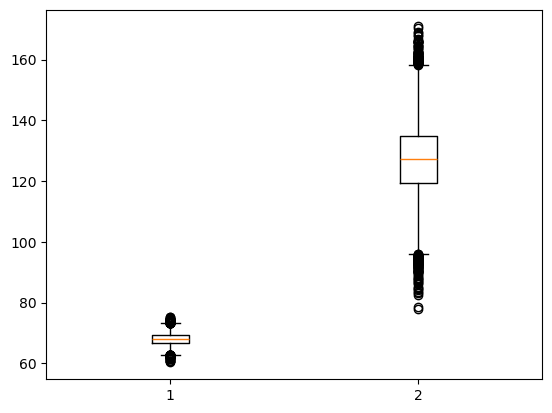

In [68]:
plt.boxplot(df)


<function matplotlib.pyplot.show(close=None, block=None)>

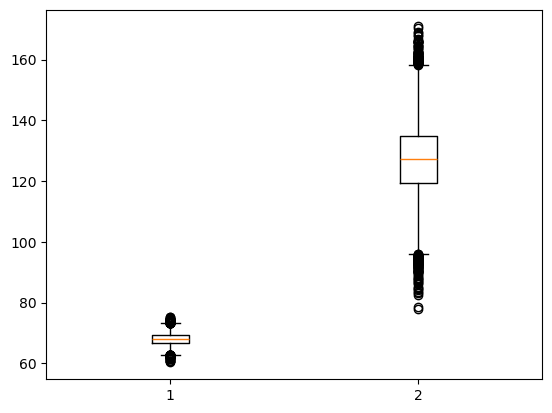

In [69]:
plt.boxplot(df)
plt.show

In [84]:
print(df.columns)

Index(['height', 'weight'], dtype='object')


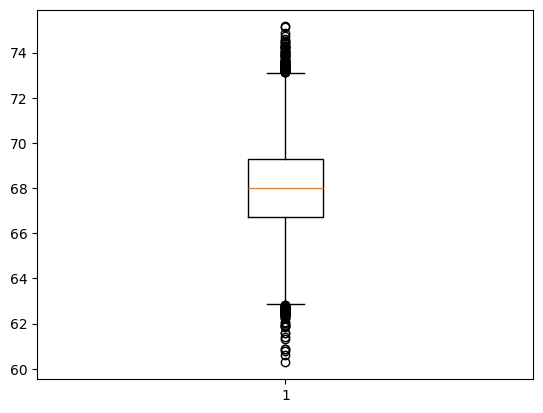

In [87]:
plt.boxplot(df["height"])
plt.show()

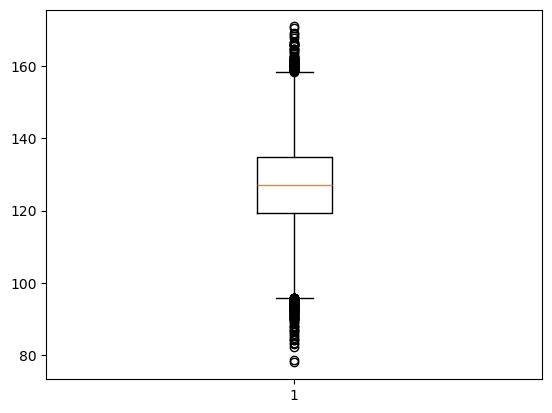

In [88]:
plt.boxplot(df["weight"])
plt.show()

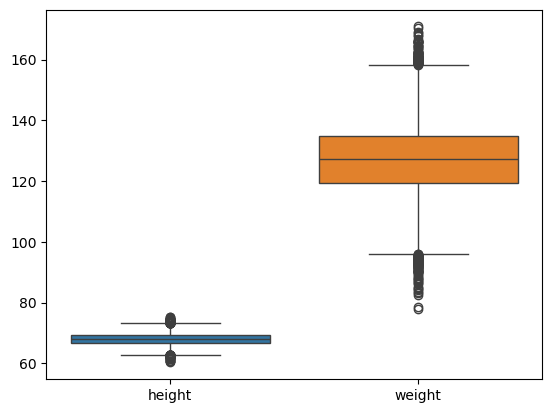

In [91]:
sns.boxplot(df)
plt.show()

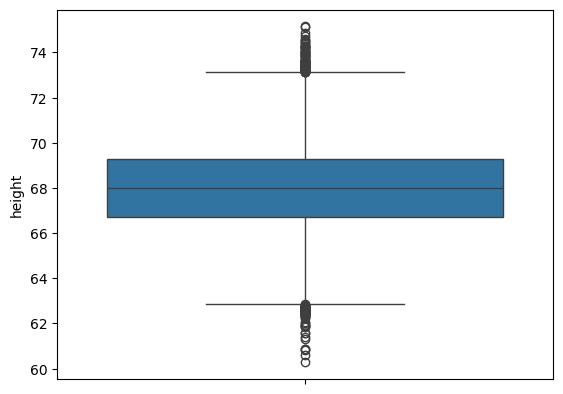

In [92]:
sns.boxplot(df["height"])
plt.show()

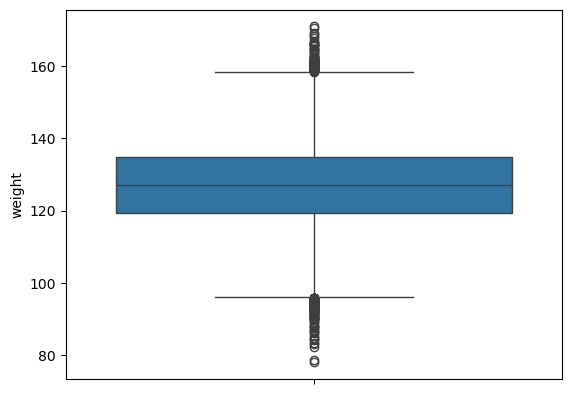

In [93]:
sns.boxplot(df["weight"])
plt.show()

### Identifying Errors using IOR

In [95]:
df["height"]

0        65.78331
1        71.51521
2        69.39874
3        68.21660
4        67.78781
           ...   
24995    69.50215
24996    64.54826
24997    64.69855
24998    67.52918
24999    68.87761
Name: height, Length: 25000, dtype: float64

In [96]:
q1=df["height"].quantile(0.25)

In [97]:
q1

np.float64(66.7043975)

In [98]:
q3=df["height"].quantile(0.75)

In [99]:
q3

np.float64(69.2729575)

In [100]:
iqr=q3-q1

In [101]:
iqr

np.float64(2.568560000000005)

In [103]:
df["height"].describe()

count    25000.000000
mean        67.993114
std          1.901679
min         60.278360
25%         66.704397
50%         67.995700
75%         69.272958
max         75.152800
Name: height, dtype: float64

In [104]:
lowerlimit=q1-(1.5*iqr)

In [105]:
upperlimit=q1+(1.5*iqr)

In [106]:
lowerlimit

np.float64(62.85155749999999)

In [107]:
upperlimit

np.float64(70.55723750000001)

In [109]:
df["height"] < lowerlimit

0        False
1        False
2        False
3        False
4        False
         ...  
24995    False
24996    False
24997    False
24998    False
24999    False
Name: height, Length: 25000, dtype: bool

In [110]:
df[df["height"] < lowerlimit]

,height,weight
412,62.01666,109.08480
1133,62.75039,114.49000
1244,62.64242,100.19820
2186,62.60611,129.76000
2237,62.78196,119.84700
...,...,...
22778,62.48689,111.81650
22945,61.92639,78.01476
23041,62.37478,129.29000
24244,62.26498,104.13480


In [111]:
df["height"] > upperlimit

0        False
1         True
2        False
3        False
4        False
         ...  
24995    False
24996    False
24997    False
24998    False
24999    False
Name: height, Length: 25000, dtype: bool

In [112]:
df[df["height"] > upperlimit]

,height,weight
1,71.51521,136.4873
15,71.09160,139.9975
18,71.23033,137.9025
26,70.84235,142.4235
33,70.59505,136.2225
...,...,...
24926,71.69485,154.4811
24939,72.35889,143.9547
24973,71.32072,125.5928
24991,71.91656,128.2840


In [117]:
(df["height"] < lowerlimit) | (df["height"] > upperlimit)

0        False
1         True
2        False
3        False
4        False
         ...  
24995    False
24996    False
24997    False
24998    False
24999    False
Name: height, Length: 25000, dtype: bool

In [118]:
df[(df["height"] < lowerlimit) | (df["height"] > upperlimit)]

,height,weight
1,71.51521,136.4873
15,71.09160,139.9975
18,71.23033,137.9025
26,70.84235,142.4235
33,70.59505,136.2225
...,...,...
24926,71.69485,154.4811
24939,72.35889,143.9547
24973,71.32072,125.5928
24991,71.91656,128.2840


###Trimming

In [119]:
df[(df["height"] < lowerlimit) | (df["height"] > upperlimit)].index

Index([    1,    15,    18,    26,    33,    34,    64,    71,    92,   131,
       ...
       24889, 24893, 24910, 24917, 24921, 24926, 24939, 24973, 24991, 24992],
      dtype='int64', length=2346)

In [120]:
ind=df[(df["height"] < lowerlimit) | (df["height"] > upperlimit)].index

In [121]:
ind

Index([    1,    15,    18,    26,    33,    34,    64,    71,    92,   131,
       ...
       24889, 24893, 24910, 24917, 24921, 24926, 24939, 24973, 24991, 24992],
      dtype='int64', length=2346)

In [122]:
df.drop(ind)

,height,weight
0,65.78331,112.9925
2,69.39874,153.0269
3,68.21660,142.3354
4,67.78781,144.2971
5,68.69784,123.3024
...,...,...
24995,69.50215,118.0312
24996,64.54826,120.1932
24997,64.69855,118.2655
24998,67.52918,132.2682


In [123]:
df.shape

(25000, 2)

In [124]:
#df.drop(ind,inplace = True)

###Capping

In [125]:
df["height"]

0        65.78331
1        71.51521
2        69.39874
3        68.21660
4        67.78781
           ...   
24995    69.50215
24996    64.54826
24997    64.69855
24998    67.52918
24999    68.87761
Name: height, Length: 25000, dtype: float64

In [127]:
df["height"].map(lambda x : x + 100) 

0        165.78331
1        171.51521
2        169.39874
3        168.21660
4        167.78781
           ...    
24995    169.50215
24996    164.54826
24997    164.69855
24998    167.52918
24999    168.87761
Name: height, Length: 25000, dtype: float64

In [128]:
df["height"].map(lambda x :lowerlimit if x < lowerlimit else upperlimit if x > upperlimit else x)

0        65.783310
1        70.557238
2        69.398740
3        68.216600
4        67.787810
           ...    
24995    69.502150
24996    64.548260
24997    64.698550
24998    67.529180
24999    68.877610
Name: height, Length: 25000, dtype: float64

In [130]:
df["height"]=df["height"].map(lambda x :lowerlimit if x < lowerlimit else upperlimit if x > upperlimit else x)

In [131]:
df["height"]

0        65.783310
1        70.557238
2        69.398740
3        68.216600
4        67.787810
           ...    
24995    69.502150
24996    64.548260
24997    64.698550
24998    67.529180
24999    68.877610
Name: height, Length: 25000, dtype: float64

In [133]:
df[(df["height"] < lowerlimit) | (df["height"] > upperlimit)]

,height,weight


<Axes: ylabel='height'>

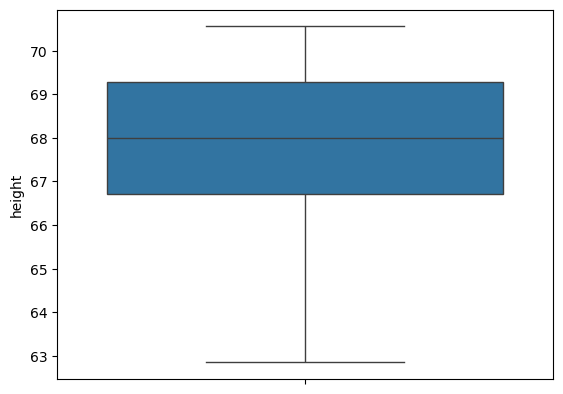

In [136]:
sns.boxplot(df["height"])

### Weight Column

In [137]:
df["weight"]

0        112.9925
1        136.4873
2        153.0269
3        142.3354
4        144.2971
           ...   
24995    118.0312
24996    120.1932
24997    118.2655
24998    132.2682
24999    124.8742
Name: weight, Length: 25000, dtype: float64

<Axes: ylabel='weight'>

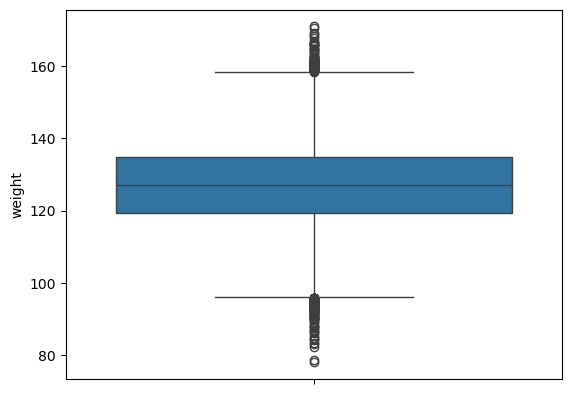

In [138]:
sns.boxplot(df["weight"])

In [139]:
qw1=df["weight"].quantile(0.25)

In [140]:
qw1

np.float64(119.308675)

In [141]:
qw3=df["weight"].quantile(0.75)

In [142]:
qw3

np.float64(134.89285)

In [143]:
iqrw=qw3-qw1

In [144]:
iqrw

np.float64(15.584175000000016)

In [145]:
df["weight"].describe()

count    25000.000000
mean       127.079421
std         11.660898
min         78.014760
25%        119.308675
50%        127.157750
75%        134.892850
max        170.924000
Name: weight, dtype: float64

In [146]:
lower=qw1-(1.5*iqrw)

In [147]:
lower

np.float64(95.93241249999997)

In [148]:
upper=qw3+(1.5*iqrw)

In [149]:
upper

np.float64(158.26911250000003)

In [151]:
(df["weight"] < lower) | (df["weight"] > upper)

0        False
1        False
2        False
3        False
4        False
         ...  
24995    False
24996    False
24997    False
24998    False
24999    False
Name: weight, Length: 25000, dtype: bool

In [152]:
df[(df["weight"] < lower) | (df["weight"] > upper)]

,height,weight
156,70.557238,158.95620
249,65.938950,84.35980
293,69.134380,92.74955
367,70.557238,168.22900
446,69.168070,162.41090
...,...,...
24187,69.211550,161.85040
24610,66.568040,82.38298
24750,70.557238,159.63440
24835,65.173390,94.40946


In [153]:
df1=df.copy()

In [154]:
##Trimming

In [155]:
df[(df["weight"] < lower) | (df["weight"] > upper)]

,height,weight
156,70.557238,158.95620
249,65.938950,84.35980
293,69.134380,92.74955
367,70.557238,168.22900
446,69.168070,162.41090
...,...,...
24187,69.211550,161.85040
24610,66.568040,82.38298
24750,70.557238,159.63440
24835,65.173390,94.40946


In [156]:
df[(df["weight"] < lower) | (df["weight"] > upper)].index

Index([  156,   249,   293,   367,   446,   472,   698,   727,   733,  1045,
       ...
       23272, 23344, 23544, 23734, 23759, 24187, 24610, 24750, 24835, 24889],
      dtype='int64', length=191)

In [159]:
indw=df[(df["weight"] < lower) | (df["weight"] > upper)].index

In [160]:
indw

Index([  156,   249,   293,   367,   446,   472,   698,   727,   733,  1045,
       ...
       23272, 23344, 23544, 23734, 23759, 24187, 24610, 24750, 24835, 24889],
      dtype='int64', length=191)

In [161]:
df.drop(indw)

,height,weight
0,65.783310,112.9925
1,70.557238,136.4873
2,69.398740,153.0269
3,68.216600,142.3354
4,67.787810,144.2971
...,...,...
24995,69.502150,118.0312
24996,64.548260,120.1932
24997,64.698550,118.2655
24998,67.529180,132.2682


In [162]:
df.drop(indw, inplace = True)

In [164]:
df[(df["weight"] < lower) | (df["weight"] > upper)]

,height,weight


<Axes: ylabel='weight'>

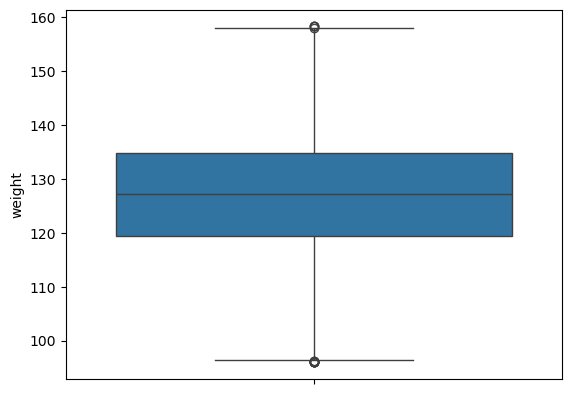

In [165]:
sns.boxplot(df["weight"])

In [166]:
###Capping

In [173]:
df1

,height,weight
0,65.783310,112.9925
1,70.557238,136.4873
2,69.398740,153.0269
3,68.216600,142.3354
4,67.787810,144.2971
...,...,...
24995,69.502150,118.0312
24996,64.548260,120.1932
24997,64.698550,118.2655
24998,67.529180,132.2682


In [174]:
df1[(df1["weight"] < lower) | (df1["weight"] > upper)]

,height,weight
156,70.557238,158.95620
249,65.938950,84.35980
293,69.134380,92.74955
367,70.557238,168.22900
446,69.168070,162.41090
...,...,...
24187,69.211550,161.85040
24610,66.568040,82.38298
24750,70.557238,159.63440
24835,65.173390,94.40946


In [175]:
df1["weight"].map(lambda x : lower if x < lower else upper if x > upper else x)

0        112.9925
1        136.4873
2        153.0269
3        142.3354
4        144.2971
           ...   
24995    118.0312
24996    120.1932
24997    118.2655
24998    132.2682
24999    124.8742
Name: weight, Length: 25000, dtype: float64

In [176]:
df1["weight"]=df1["weight"].map(lambda x : lower if x < lower else upper if x > upper else x)

In [177]:
df1

,height,weight
0,65.783310,112.9925
1,70.557238,136.4873
2,69.398740,153.0269
3,68.216600,142.3354
4,67.787810,144.2971
...,...,...
24995,69.502150,118.0312
24996,64.548260,120.1932
24997,64.698550,118.2655
24998,67.529180,132.2682


In [178]:
df1[(df1["weight"] < lower) | (df1["weight"] > upper)]

,height,weight


<Axes: ylabel='weight'>

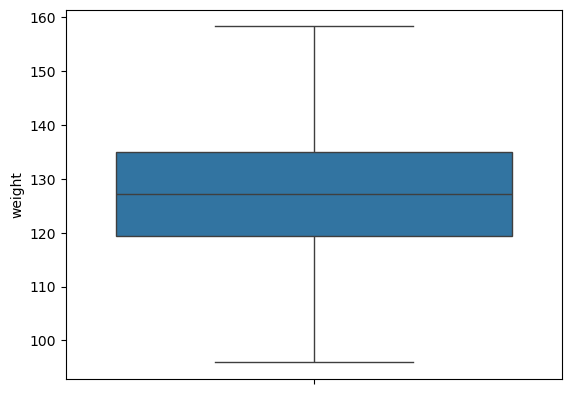

In [180]:
sns.boxplot(df1["weight"])

### Data Seperation

In [181]:
dfiris = pd.read_csv(r"C:\Users\Ravishankar Kumar\Desktop\Iris.csv")

In [182]:
dfiris

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [183]:
dfiris.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [184]:
dfiris.shape

(150, 6)

In [186]:
dfiris.drop("Id", axis = 1, inplace = True)

In [187]:
dfiris

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [188]:
dfiris.columns

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [192]:
dfiris[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'
        ]]

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [193]:
dfiris.drop("Species", axis=1)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [194]:
X=dfiris.drop("Species", axis=1)

In [198]:
y = dfiris["Species"]

In [199]:
y

0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
145    Iris-virginica
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica
149    Iris-virginica
Name: Species, Length: 150, dtype: object

In [200]:
dfiris.head(30)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


In [201]:
dfiris.sample(30)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
120,6.9,3.2,5.7,2.3,Iris-virginica
77,6.7,3.0,5.0,1.7,Iris-versicolor
13,4.3,3.0,1.1,0.1,Iris-setosa
129,7.2,3.0,5.8,1.6,Iris-virginica
62,6.0,2.2,4.0,1.0,Iris-versicolor
59,5.2,2.7,3.9,1.4,Iris-versicolor
138,6.0,3.0,4.8,1.8,Iris-virginica
78,6.0,2.9,4.5,1.5,Iris-versicolor
47,4.6,3.2,1.4,0.2,Iris-setosa
119,6.0,2.2,5.0,1.5,Iris-virginica
